# Partie V : Votre étude

Réalisez votre propre étude par binôme :
- en modifiant les bases de test et/ou d'apprentissage c'est-à-dire en créant  votre propre base d'apprentissage et votre base de test à partir du corpus et des voix et bruits que vous aurez enregistrés
- en rajoutant davantage de classes (jusqu'à 13 ordres vocaux disponibles) 
- en utilisant d'autres méthodes de réduction de dimension (t-SNE...)
le tout en testant les différentes approches et en interprétant les résultats, à synthétiser sur un rapport en pdf. 


**Paramètres pour enregistrements audio de vos voix perso:**

16 KHz, mono, 16 bits, format *.wav*

Nous avons choisi les mots suivants : *attaque, auto-destruction, Avance, Descend, Esquive, Largue, Leurre, Looping, Monte, Recule, Revient, Tourne-droite, Tourne-Gauche*.

Il sera intéressant de voir si le modèle confond les mots proches comme Largue et Leurre, Recule et Revient, ou Tourne-droite et Tourne-gauche.

Nous avons collaboré avec Arthur et Emeline pour avoir 4 nouvelles voix dans notre dataset.

Nous avons des accents différents :
* Accent Parisien pour Arthur et Victor
* Accent Marseillé pour Emeline
* Accent Toulousain pour Maël

Pour chaque mot, nous avons enregistré 5 versions différentes:

* Avec du bruit
* Elocution normale
* Elocution forte.
* Elocution lente
* Elocution rapide

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
import math
import numpy.random as rnd
import seaborn as sns
import librosa
from os import listdir
from os.path import isfile, join
import glob
import re

In [2]:
data = []
min_duration = None
max_duration = None
label = []
words = ["Attaque", "AutoDestruction", "Avance", "Descends", "Esquive", "Largue", "Leurre", "Looping",
        "Monte", "Recule", "Reviens", "TourneDroite", "TourneGauche"]

for word in listdir("Audios/"):
    if word in words:
        for file_name in listdir(f"Audios/{word}/"):
            if file_name.split(sep=".")[-1] == "wav":
                path = f"Audios/{word}/{file_name}"
                record = librosa.load(path)[0]
                data.append(record)
                # Computation of the minimal size of recordings
                if min_duration is None or record.shape[0] < min_duration:
                    min_duration = record.shape[0] 
                if max_duration is None or record.shape[0] > max_duration:
                    max_duration = record.shape[0] 

                label.append(words.index(word))
        
fs = librosa.load(path)[1] # Sampling frequency
print(f'The smallest record contains {min_duration} samples, and the sample frequency is {fs} Hz')
print(f'The longest record contains {max_duration} samples, and the sample frequency is {fs} Hz')

The smallest record contains 8193 samples, and the sample frequency is 22050 Hz
The longest record contains 55988 samples, and the sample frequency is 22050 Hz


In [3]:
size = 56000

In [4]:
genres = []
min_duration = None
words = ["Attaque", "AutoDestruction", "Avance", "Descends", "Esquive", "Largue", "Leurre", "Looping",
        "Monte", "Recule", "Reviens", "TourneDroite", "TourneGauche"]
list_genres = ['M', 'F']

for file_name in glob.glob('FichierTest/*.wav'):
    record = librosa.load(file_name)[0]
    data.append(record)
    # Computation of the minimal size of recordings
    if min_duration is None or record.shape[0] < min_duration:
        min_duration = record.shape[0] 
    
    for i, word in enumerate(words):
        if re.search(word.lower(), file_name):
            label.append(i)

fs = librosa.load(file_name)[1] # Sampling frequency
genres = np.array(genres)
print(f'The smallest record contains {min_duration} samples, and the sample frequency is {fs} Hz')


The smallest record contains 18522 samples, and the sample frequency is 22050 Hz


In [5]:
print(len(data))
print(len(label))

314
314


On a pas mit de blanc dans les audios, on ne souhaite donc pas raccourcir les audios, cela reviendrait à couper les mots. On va donc utiliser du padding pour se ramener à la taille de 

In [6]:

""" Si la durée est supérieure à size """
def trim(record):
    half_duration = max_duration//2

    # First, we compute the barycenter of energy along time. We interpret it as the moment when the word appears
    barycenter = int(np.floor(np.multiply(np.power(record,2),np.arange(0,record.shape[0],1)).sum()/np.power(record,2).sum()))

    # Second, we adjust the barycenter to be in the index range
    if barycenter-half_duration < 0:
        barycenter += half_duration-barycenter
    if barycenter+half_duration >= record.shape[0]:
        barycenter -= barycenter+half_duration - record.shape[0]
    
    # Finally, we trim the recording around the barycenter 
    return record[barycenter-half_duration:barycenter+half_duration]

""" Si la durée est inférieure à size """
def padding(record):
    output = np.zeros(max_duration)
    half_record_size = len(record)//2
    half_size = size // 2
    start = half_size - half_record_size
    end = start + len(record)
    output[start : end] = record
    return output

def audio_preprocess(record):
    if len(record) > max_duration:
        return trim(record)
    elif len(record) < max_duration:
        return padding(record)
    return record    

In [7]:
max_duration=19000

print(max_duration)

55988


In [8]:
X = np.empty((len(data),max_duration))
for i in range(len(data)):
    X[i,:] = audio_preprocess(data[i])

y = np.array(label)
print(f'Shape of inputs X is{X.shape} and size of targets class is {y.shape}')

Shape of inputs X is(314, 55988) and size of targets class is (314,)


## Transformation des données d'entrée

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

def med_std(array):
    std = np.std(array, axis=-1)
    med = np.median(array, axis=-1)
    return np.concatenate([std, med], axis=-1)


class MFCC(BaseEstimator, TransformerMixin):
    
    def __init__(self, time_statistics, n_mfcc):
        self.time_statistics = time_statistics
        self.n_mfcc = n_mfcc
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        MFCC_X = librosa.feature.mfcc(y=X, sr=fs, n_mfcc=self.n_mfcc)
        time_stat = self.time_statistics(MFCC_X)
        return time_stat
    
    def __repere__(self):
        print("MFCC")

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preproc = Pipeline([('mfcc', MFCC(med_std, 10)), ("scaler", StandardScaler())])
transformed_X = preproc.fit_transform(X)

## Split dataset

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

314


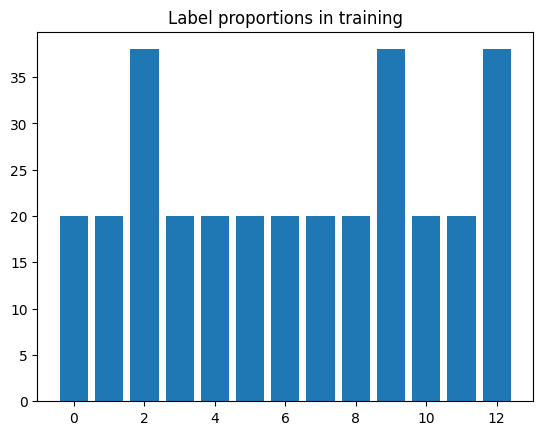

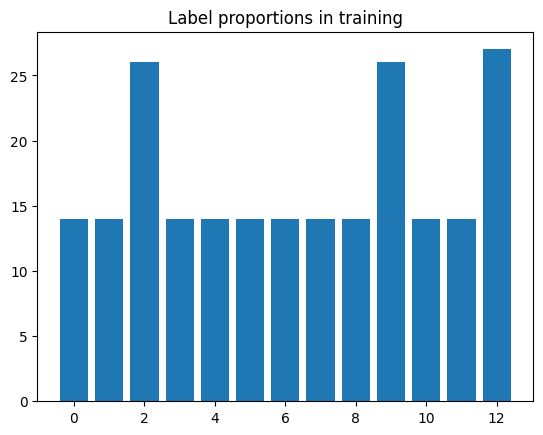

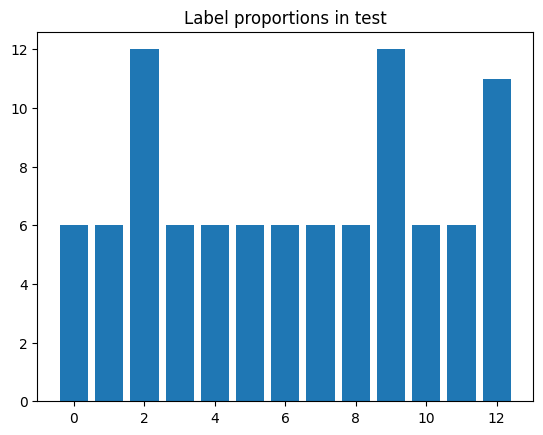

In [12]:
label_list = range(np.max(y)+1)
label_count_train = [np.sum(y_train == i) for i in label_list]
label_count_test = [np.sum(y_test == i) for i in label_list]
label_count_original = [np.sum(y == i) for i in label_list]
print(np.sum(label_count_original))

plt.bar(label_list, label_count_original)
plt.title("Label proportions in training")
plt.show()
    
plt.bar(label_list, label_count_train)
plt.title("Label proportions in training")
plt.show()

plt.bar(label_list, label_count_test)
plt.title("Label proportions in test")
plt.show()

## Regression Multinomiale

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [14]:
def feature_grid_search():
    estimators = [('feature', MFCC(med_std, 0)), ("scaler", StandardScaler()), 
                  ('regression', LogisticRegression(solver="saga", max_iter=300, class_weight="balanced"))]
        
    pipeline = Pipeline(estimators)

    params = {'feature__n_mfcc': [10, 100, 400],
             'regression__penalty': ["l1", "l2", None],
             'regression__C': [0.1, 1, 10]}
    
    feature_grid_search = GridSearchCV(pipeline, params, scoring="f1_micro", cv=2, verbose=1, n_jobs=-1)
    return feature_grid_search


MFCC_CV_scaled = feature_grid_search()
MFCC_model_scaled = MFCC_CV_scaled.fit(X, y)
print(f"Best parameters for scaled MFCC: {MFCC_model_scaled.best_params_}")
print(f"Best score for scaled MFCC: {MFCC_model_scaled.best_score_}")

Fitting 2 folds for each of 27 candidates, totalling 54 fits
Best parameters for scaled MFCC: {'feature__n_mfcc': 10, 'regression__C': 10, 'regression__penalty': 'l1'}
Best score for scaled MFCC: 0.36624203821656054


/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix"):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels if labels else np.unique(y_true), 
                yticklabels=labels if labels else np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(f"f1 micro: {np.round(f1_score(y_true, y_pred, average='micro'), 3)}")
    print(f"f1 macro: {np.round(f1_score(y_true, y_pred, average='macro'), 3)}")
    print(f"f1 weighted: {np.round(f1_score(y_true, y_pred, average='weighted'), 3)}")
    return matrix

In [20]:
model = Pipeline([('feature', MFCC(med_std, 10)), ("scaler", StandardScaler()), 
                  ('regression', LogisticRegression(solver="saga", max_iter=1000, C=1, 
                  penalty='l2', class_weight="balanced"))])

model.fit(X_train, y_train)
prediction = model.predict(X_test)

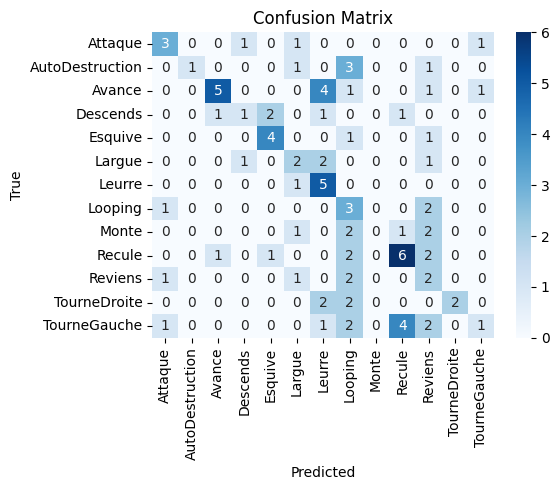

f1 micro: 0.368
f1 macro: 0.348
f1 weighted: 0.358


/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/h

/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/n7student/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/h

In [21]:
ConfusionMatrix_best_FFT_scaled = plot_confusion_matrix(y_test, prediction,
                                  labels=words, title="Confusion Matrix")